In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data Cleaning

## Inspecting Values

- There is missing data or null values
- However, there is something wierd going on with bedroom and bedroom_num
- Other columns seem to have all valid values

In [2]:
df = pd.read_csv('irish_rent_specific.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22484 entries, 0 to 22483
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rent_euro            22484 non-null  float64
 1   year                 22484 non-null  int64  
 2   half                 22484 non-null  int64  
 3   half_year            22484 non-null  object 
 4   time_period          22484 non-null  int64  
 5   county               22484 non-null  object 
 6   province             22484 non-null  object 
 7   area                 22484 non-null  object 
 8   location             22484 non-null  object 
 9   property_type        22484 non-null  object 
 10  bedrooms             22484 non-null  object 
 11  bedrooms_num         22484 non-null  float64
 12  is_dublin            22484 non-null  bool   
 13  is_city              22484 non-null  bool   
 14  is_county_aggregate  22484 non-null  bool   
 15  latitude             22484 non-null 

In [4]:
df.describe(include='all')

,rent_euro,year,half,half_year,time_period,county,province,area,location,property_type,bedrooms,bedrooms_num,is_dublin,is_city,is_county_aggregate,latitude,longitude
count,22484.000000,22484.000000,22484.000000,22484,22484.000000,22484,22484,22484,22484,22484,22484,22484.000000,22484,22484,22484,22484.000000,22484.000000
unique,NaN,NaN,NaN,11,NaN,26,4,345,357,5,6,NaN,2,2,2,NaN,NaN
top,NaN,NaN,NaN,2020H2,NaN,Dublin,Leinster,Dublin,Dublin,Apartment,1 to 3 bed,NaN,False,False,False,NaN,NaN
freq,NaN,NaN,NaN,2850,NaN,7669,13636,323,323,9679,7219,NaN,14815,13858,16497,NaN,NaN
mean,1278.218131,2021.892012,1.483900,NaN,5.267924,NaN,NaN,NaN,NaN,NaN,NaN,2.113169,NaN,NaN,NaN,53.154368,-7.303953
std,508.850286,1.547651,0.499752,NaN,3.085939,NaN,NaN,NaN,NaN,NaN,NaN,0.758480,NaN,NaN,NaN,0.626205,1.091347
min,401.580000,2020.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,51.898500,-9.566900
25%,878.625000,2021.000000,1.000000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,NaN,NaN,NaN,52.836500,-8.475600
50%,1170.440000,2022.000000,1.000000,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,53.349800,-6.909900
75%,1613.305000,2023.000000,2.000000,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,53.349800,-6.260300


In [5]:
df.half.value_counts()

half
1    11604
2    10880
Name: count, dtype: int64

In [6]:
df.half_year.value_counts()

half_year
2020H2    2850
2020H1    2707
2021H1    2488
2021H2    2342
2022H2    2159
2022H1    1957
2023H2    1920
2023H1    1761
2024H2    1609
2024H1    1456
2025H1    1235
Name: count, dtype: int64

In [7]:
df.bedrooms.value_counts()

bedrooms
1 to 3 bed       7219
1 to 2 bed       4565
Two bed          3605
Three bed        3468
One bed          1965
Four plus bed    1662
Name: count, dtype: int64

In [8]:
df.bedrooms_num.value_counts()

bedrooms_num
2.0    10824
1.5     4565
3.0     3468
1.0     1965
4.0     1662
Name: count, dtype: int64

In [9]:
df.year.value_counts()

year
2020    5557
2021    4830
2022    4116
2023    3681
2024    3065
2025    1235
Name: count, dtype: int64

In [10]:
df.location.value_counts()

location
Dublin                  323
Cork                    306
Galway                  285
Cork City               281
Limerick                271
                       ... 
Killester, Dublin 5       1
Ballina, Tipperary        1
Newcastle, Galway         1
Dunmanway, Cork           1
Poleberry, Waterford      1
Name: count, Length: 357, dtype: int64

In [11]:
df.province.value_counts()

province
Leinster    13636
Munster      5153
Connacht     2559
Ulster       1136
Name: count, dtype: int64

In [12]:
df.area.value_counts()

area
Dublin            323
Cork              306
Galway            285
Cork City         281
Limerick          271
                 ... 
Kinnegad            1
Newcastle           1
Ballyjamesduff      1
Dunmanway           1
Poleberry           1
Name: count, Length: 345, dtype: int64

In [13]:
df.county.value_counts()

county
Dublin       7669
Cork         1833
Kildare      1070
Galway       1066
Limerick      822
Tipperary     740
Meath         739
Wicklow       704
Kerry         649
Mayo          609
Louth         605
Wexford       593
Waterford     580
Westmeath     534
Clare         529
Offaly        433
Donegal       429
Laois         406
Sligo         383
Carlow        380
Monaghan      366
Cavan         341
Roscommon     325
Longford      308
Kilkenny      195
Leitrim       176
Name: count, dtype: int64

In [14]:
df.time_period.value_counts()

time_period
2     2850
1     2707
3     2488
4     2342
6     2159
5     1957
8     1920
7     1761
10    1609
9     1456
11    1235
Name: count, dtype: int64

In [15]:
df.property_type.value_counts()

property_type
Apartment              9679
Semi detached house    4607
Terrace house          4168
Detached house         2250
Other flats            1780
Name: count, dtype: int64

## Fixing bedrooms and bedrooms_nums

- The values in these column seem inconsistent and therefore cannot be used
- I have converted them to a new column bedroom_max that only takes the max amount of bedroom for each accomodation

In [16]:
map = {"1 to 3 bed" : '3', "1 to 2 bed" : '2', "Two bed" : '2', "Three bed" : '3', "One bed" : '1', "Four plus bed" : '4'}

df["bedrooms_max"] = df["bedrooms"].map(map)

In [17]:
df.bedrooms_max.value_counts()

bedrooms_max
3    10687
2     8170
1     1965
4     1662
Name: count, dtype: int64

In [18]:
df.to_csv('irish_rent_specific_cleaned.csv', index=False)

# EDA

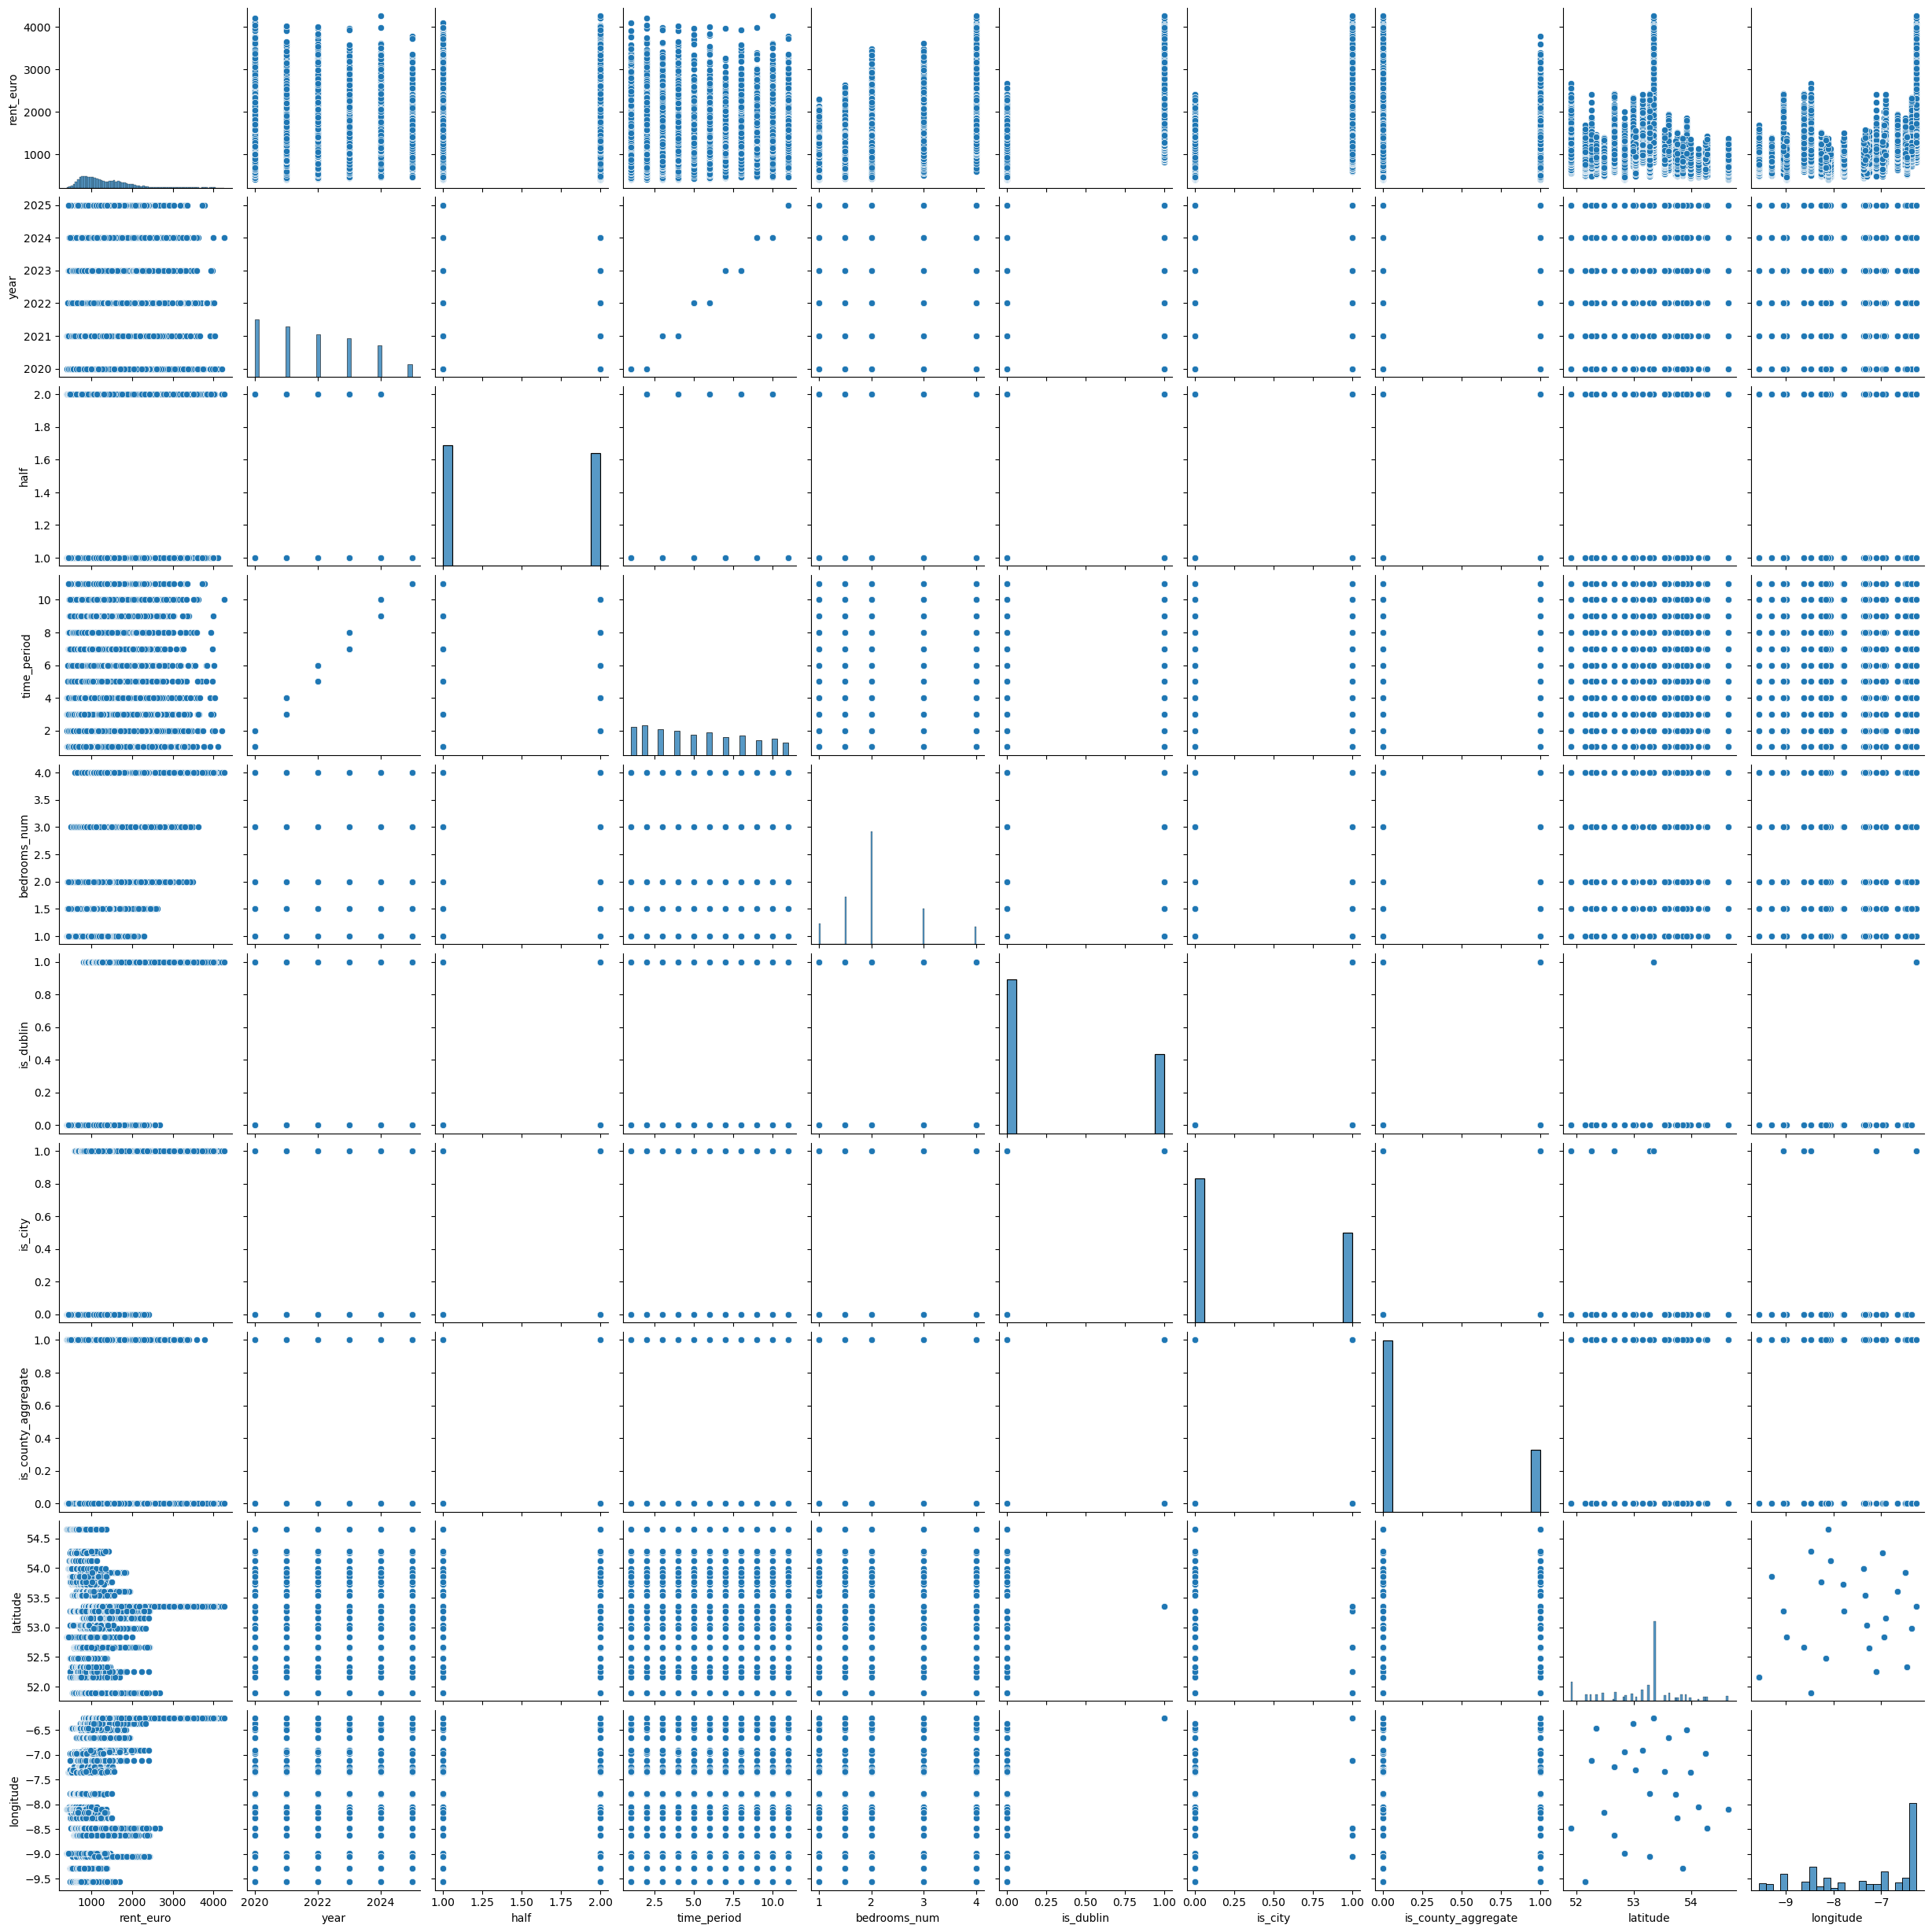

In [19]:
sns.pairplot(df)

In [20]:
labels = {
    'bedrooms_num': 'Number of Bedrooms',
    'rent_euro': 'Rent in Euros',
    'is_city': 'Is City',
    'county': 'County',
    'year': 'Year',
    'property_type': 'Property Type',
    'bedrooms_max': 'Max Bedrooms'
}

In [21]:
px.histogram(df, x="property_type", color="property_type", title="Property Type Distribution", template="plotly_dark" , labels=labels)

In [22]:
px.histogram(df, x="bedrooms_max", color="bedrooms_max", title="Bedroom Distribution", template="plotly_dark", labels=labels)

In [23]:
fig = px.histogram(df, x="property_type", color="bedrooms_max", title="Bedroom Distribution", template="plotly_dark", barmode="group", labels=labels)
fig.update_layout(yaxis_title="Number of Properties")

In [24]:
px.pie(df, names="is_city", title="City vs County Distribution", template="plotly_dark")

In [25]:
fig = px.histogram(df, x="county", color="is_city", title="County Distribution of Accommodations", template="plotly_dark", labels=labels)
fig.update_layout(yaxis_title="Number of Properties")

In [26]:
fig = px.histogram(df, x='rent_euro', title="Rent Distribution", template="plotly_dark", log_x=False, labels=labels)
fig.update_layout(yaxis_title="Number of Properties")

In [27]:
fig =px.histogram(df, x='rent_euro', title="Rent Distribution", template="plotly_dark", log_x=True, labels={"rent_euro": "Rent in Euros (Log Scale)"})
fig.update_layout(yaxis_title="Number of Properties")

In [28]:
grouped_yearly_rent = df.groupby('year')['rent_euro'].mean().reset_index()
fig = px.line(grouped_yearly_rent, x='year', y='rent_euro', title="Average Rent Over Time", template="plotly_dark", labels=labels)
fig.add_annotation(x=2022, y=grouped_yearly_rent[grouped_yearly_rent['year'] == 2022]['rent_euro'].values[0],
            text=f"Average Rent: €{grouped_yearly_rent[grouped_yearly_rent['year'] == 2022]['rent_euro'].values[0]:.2f}",
            showarrow=True,
            arrowhead=1)

fig.add_annotation(x=2025, y=grouped_yearly_rent[grouped_yearly_rent['year'] == 2025]['rent_euro'].values[0],
            text=f"Average Rent: €{grouped_yearly_rent[grouped_yearly_rent['year'] == 2025]['rent_euro'].values[0]:.2f}",
            showarrow=True,
            arrowhead=1)

In [29]:
grouped_yearly_rent = df.groupby(['year', 'is_city'])['rent_euro'].mean().reset_index()
px.line(grouped_yearly_rent, x='year', y='rent_euro', color='is_city', title="Average Rent Over Time by Location", template="plotly_dark", range_y=[600, 2200], markers=True, hover_data={'rent_euro': ':.2f'}, labels=labels)

In [30]:
grouped_yearly_rent = df.groupby(['year', 'property_type', 'is_city'])['rent_euro'].mean().reset_index()
px.line(grouped_yearly_rent, x='year', y='rent_euro',
         color='property_type',
           title="Average Rent Over Time by Property Type (City)",
             template="plotly_dark", range_y=[600, 2200],
               markers=True, hover_data={'rent_euro': ':.2f'},
                 labels=labels,
                 facet_col='is_city')
